# Portfolio optimization — `qufin.portfolio`

> *"Diversification is the only free lunch in investing."* — Harry Markowitz

Markowitz **mean–variance** optimization formalises that lunch: combine assets
so the portfolio earns the most return per unit of risk. The inputs are an
expected-return vector $\mu$ and a covariance matrix $\Sigma$; the outputs are
weights $w$. The key portfolios:

* **Minimum variance** — $\min_w w'\Sigma w$. Ignores $\mu$ entirely, so it's
  robust to the hardest input to estimate.
* **Maximum Sharpe (tangency)** — $\max_w (w'\mu - r_f)/\sqrt{w'\Sigma w}$. The
  best risk-adjusted portfolio — but exquisitely sensitive to $\mu$.
* **Risk parity** — every asset contributes equal risk. No $\mu$ needed.
* **Efficient frontier** — the locus of all $\min$-variance-for-a-return
  portfolios; everything optimal lives on it.

The deep practical lesson, which this notebook demonstrates head-on:
**estimation error in $\mu$ wrecks naive mean–variance**, and **covariance
shrinkage** (Ledoit–Wolf) plus $\mu$-free methods are how you fight back.

**Roadmap**

0. Data — a diversified multi-asset panel (real, with synthetic fallback)
1. Assets in risk/return space + the correlation matrix
2. Diversification — the portfolio is less risky than its parts
3. The efficient frontier + the capital market line
4. Min-variance vs max-Sharpe vs risk parity — the weights
5. Estimation risk — covariance shrinkage and an honest out-of-sample test


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from qufin.portfolio import (
    simple_returns, to_returns_matrix, annualized_returns,
    sample_cov, ledoit_wolf_cov, annualize_cov, cov_to_corr,
    min_variance, max_sharpe, risk_parity, efficient_frontier,
    portfolio_metrics,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
RF = 0.04           # annual risk-free rate
PPY = 252


## 0. Data

A genuinely diversified panel — US equities (**SPY**), long Treasuries
(**TLT**), intermediate Treasuries (**IEF**), gold (**GLD**), emerging markets
(**EEM**), and high-yield credit (**HYG**) — so the covariance structure has
real cross-asset diversification to exploit. Offline, the loader falls back to a
factor-model simulation with distinct means, vols and correlations.


In [2]:
TICKERS = ['SPY', 'TLT', 'IEF', 'GLD', 'EEM', 'HYG']

def load_prices(tickers=TICKERS, start='2010-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][tickers].dropna()
        if len(close) > 1000:
            return pl.DataFrame({t: close[t].to_numpy() for t in tickers})
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic factor-model panel')
    rng = np.random.default_rng(1)
    n = 3000
    # One market factor + idiosyncratic noise; betas/means/vols differ per asset.
    mkt = rng.normal(0.0003, 0.009, n)
    betas = np.array([1.0, -0.3, -0.1, 0.1, 1.2, 0.6])
    mus = np.array([0.0004, 0.0002, 0.00015, 0.0003, 0.0004, 0.00035])
    idio = np.array([0.004, 0.006, 0.003, 0.009, 0.011, 0.005])
    cols = {}
    for j, t in enumerate(tickers):
        r = mus[j] + betas[j] * mkt + rng.normal(0, idio[j], n)
        cols[t] = 100.0 * np.exp(np.cumsum(r))
    return pl.DataFrame(cols)

prices = load_prices()
ret_df = simple_returns(prices)
mat, names = to_returns_matrix(ret_df)
mu_map = annualized_returns(ret_df, PPY)
mu = np.array([mu_map[n] for n in names])
cov = annualize_cov(ledoit_wolf_cov(mat), PPY)
print(f'panel: {mat.shape[0]} days x {mat.shape[1]} assets: {names}')
for n_, m_ in zip(names, mu):
    print(f'  {n_}: ann.return={m_:+.1%}  ann.vol={np.sqrt(cov[names.index(n_), names.index(n_)]):.1%}')


panel: 3772 days x 6 assets: ['SPY', 'TLT', 'IEF', 'GLD', 'EEM', 'HYG']
  SPY: ann.return=+13.7%  ann.vol=17.0%
  TLT: ann.return=+2.7%  ann.vol=15.3%
  IEF: ann.return=+2.4%  ann.vol=6.8%
  GLD: ann.return=+5.4%  ann.vol=15.5%
  EEM: ann.return=+2.0%  ann.vol=21.5%
  HYG: ann.return=+5.1%  ann.vol=8.5%


## 1. Assets in risk/return space

Every asset is a point in (volatility, return) space. The **correlation matrix**
shows where the diversification comes from: bonds (TLT/IEF) tend to be
*negatively* or weakly correlated with equities (SPY/EEM) and gold (GLD) marches
to its own drum. Low or negative correlations are the raw material the optimizer
turns into risk reduction.


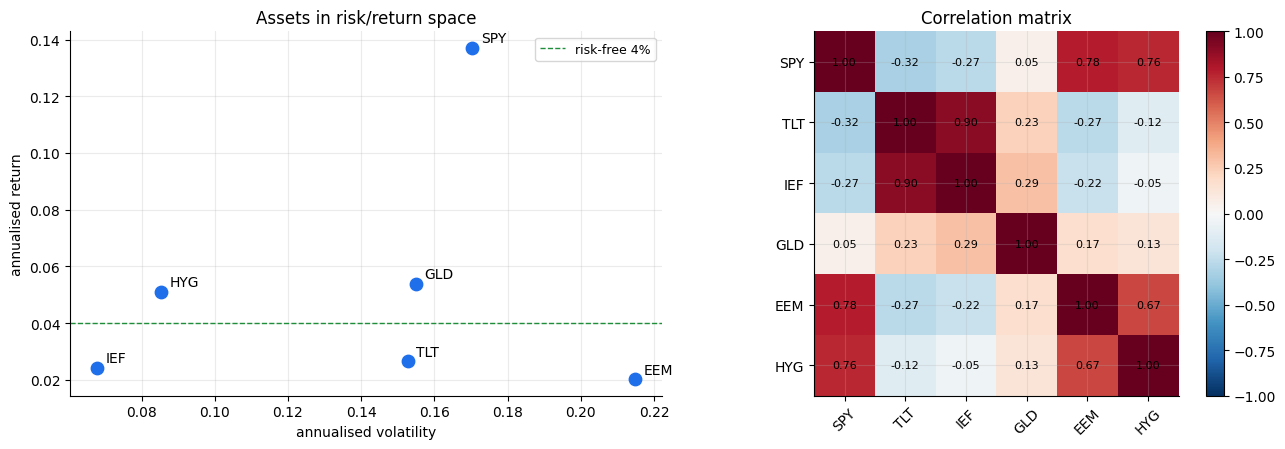

In [3]:
vols = np.sqrt(np.diag(cov))
corr = cov_to_corr(cov)

fig, (axsc, axcm) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.1, 1]})
axsc.scatter(vols, mu, s=80, color='#1f6feb', zorder=3)
for i, n_ in enumerate(names):
    axsc.annotate(n_, (vols[i], mu[i]), xytext=(6, 4), textcoords='offset points', fontsize=10)
axsc.axhline(RF, color='#1f8e3a', ls='--', lw=1, label=f'risk-free {RF:.0%}')
axsc.set_xlabel('annualised volatility'); axsc.set_ylabel('annualised return')
axsc.set_title('Assets in risk/return space'); axsc.legend(fontsize=9)

im = axcm.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axcm.set_xticks(range(len(names))); axcm.set_xticklabels(names, rotation=45)
axcm.set_yticks(range(len(names))); axcm.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        axcm.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=8)
axcm.set_title('Correlation matrix'); fig.colorbar(im, ax=axcm, fraction=0.046)
plt.tight_layout(); plt.show()


## 2. Diversification — the free lunch

An equal-weight portfolio's volatility is **strictly less** than the weighted
average of its constituents' volatilities, because imperfect correlations cancel
some risk. The gap is the diversification benefit — pure risk reduction at no
cost in expected return.


In [4]:
w_eq = np.full(len(names), 1.0 / len(names))
ew = portfolio_metrics(w_eq, mat, risk_free_rate=RF, periods_per_year=PPY)
weighted_avg_vol = float(w_eq @ vols)
print(f'weighted-average asset vol : {weighted_avg_vol:.2%}')
print(f'equal-weight portfolio vol : {ew["annualized_volatility"]:.2%}')
print(f'diversification saving      : {weighted_avg_vol - ew["annualized_volatility"]:.2%}'
      f'  ({1 - ew["annualized_volatility"]/weighted_avg_vol:.0%} lower)')
print(f'\nequal-weight Sharpe = {ew["sharpe_ratio"]:.2f}, '
      f'ann.return = {ew["annualized_return"]:.1%}, maxDD = {ew["max_drawdown"]:.1%}')


weighted-average asset vol : 14.10%
equal-weight portfolio vol : 8.20%
diversification saving      : 5.91%  (42% lower)

equal-weight Sharpe = 0.26, ann.return = 6.0%, maxDD = 21.8%


## 3. The efficient frontier and the capital market line

The **efficient frontier** is the upper edge of what's achievable: maximum
return for each level of risk. With a risk-free asset, the best portfolio is the
**tangency** (max-Sharpe) portfolio, and the straight **Capital Market Line**
from $r_f$ through it dominates the whole frontier — every investor holds the
tangency portfolio levered up or down with cash.


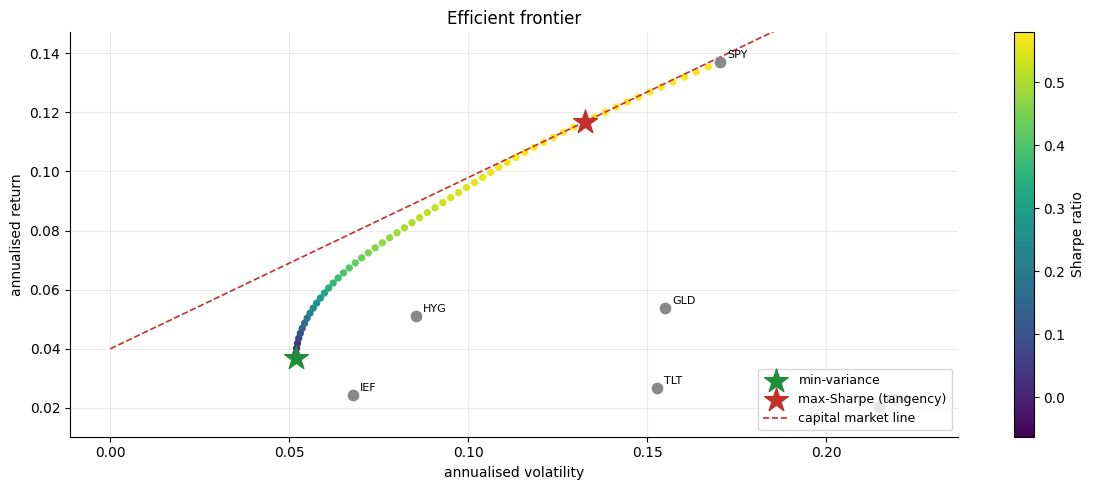

tangency Sharpe = 0.58   min-var vol = 5.2%


In [5]:
ef = efficient_frontier(mu, cov, names, n_points=60, risk_free_rate=RF)
mv = min_variance(mu, cov, names, risk_free_rate=RF)
ms = max_sharpe(mu, cov, names, risk_free_rate=RF)

fig, ax = plt.subplots()
sc = ax.scatter(ef.volatilities, ef.returns, c=ef.sharpe_ratios, cmap='viridis', s=18, zorder=2)
fig.colorbar(sc, ax=ax, label='Sharpe ratio')
ax.scatter(vols, mu, color='#888', s=55, zorder=3)
for i, n_ in enumerate(names):
    ax.annotate(n_, (vols[i], mu[i]), xytext=(5, 3), textcoords='offset points', fontsize=8)
ax.scatter(mv.expected_volatility, mv.expected_return, color='#1f8e3a', marker='*', s=320,
           zorder=4, label='min-variance')
ax.scatter(ms.expected_volatility, ms.expected_return, color='#c4302b', marker='*', s=320,
           zorder=4, label='max-Sharpe (tangency)')
xline = np.linspace(0, vols.max() * 1.05, 50)
ax.plot(xline, RF + ms.sharpe_ratio * xline, color='#c4302b', ls='--', lw=1.2,
        label='capital market line')
ax.set_xlabel('annualised volatility'); ax.set_ylabel('annualised return')
ax.set_title('Efficient frontier'); ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(min(mu.min(), RF) - 0.01, ef.returns.max() + 0.01)
plt.tight_layout(); plt.show()
print(f'tangency Sharpe = {ms.sharpe_ratio:.2f}   min-var vol = {mv.expected_volatility:.1%}')


## 4. Three optimizers, three philosophies

* **Max-Sharpe** chases return — and typically **concentrates** in whatever asset
  had the best estimated $\mu$.
* **Min-variance** hugs the lowest-risk (often bond-heavy) corner.
* **Risk parity** spreads *risk* (not dollars) evenly — the most diversified of
  the three, and it never looks at $\mu$.


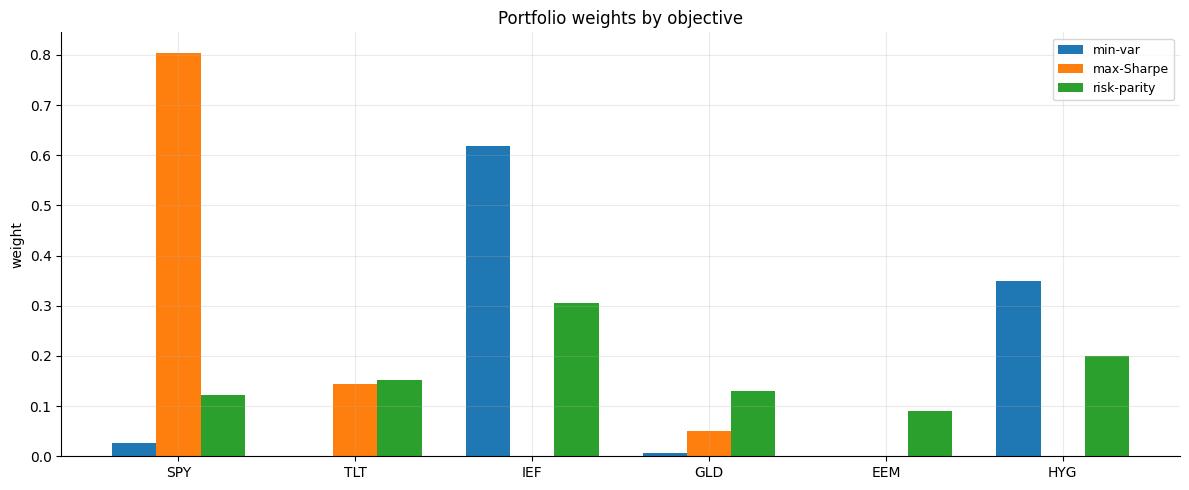

portfolio      ann.ret  ann.vol  Sharpe
min-var           3.7%     5.2%   -0.06
max-Sharpe       11.7%    13.3%    0.58
risk-parity       4.7%     6.8%    0.11


In [6]:
rp = risk_parity(cov, names, expected_returns=mu, risk_free_rate=RF)
ports = {'min-var': mv, 'max-Sharpe': ms, 'risk-parity': rp}

x = np.arange(len(names)); width = 0.25
fig, ax = plt.subplots()
for k, (label, p) in enumerate(ports.items()):
    ax.bar(x + (k - 1) * width, p.weights, width, label=label)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel('weight')
ax.set_title('Portfolio weights by objective'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'{"portfolio":<13}{"ann.ret":>9}{"ann.vol":>9}{"Sharpe":>8}')
for label, p in ports.items():
    print(f'{label:<13}{p.expected_return:>9.1%}{p.expected_volatility:>9.1%}{p.sharpe_ratio:>8.2f}')


## 5. Estimation risk — shrinkage and an out-of-sample test

Optimizers treat $\mu$ and $\Sigma$ as truth, but they're *noisy estimates*.
Two defences:

* **Covariance shrinkage** (Ledoit–Wolf) pulls the noisy sample covariance toward
  a stable target, slashing its condition number (sensitivity to noise).
* **Estimate on the past, judge on the future.** We fit weights on the first 60%
  of history and measure realised performance on the unseen last 40%. Watch the
  **IS→OOS Sharpe decay**: the $\mu$-hungry **max-Sharpe** overfits the return
  estimate and drops the most from in-sample to out-of-sample, while the
  $\mu$-free **equal-weight** and **risk-parity** books are far more stable.
  (Which portfolio *wins outright* out-of-sample depends on the sample — here an
  equity-heavy decade flatters the aggressive book — but the **fragility** of
  return-chasing is the durable lesson.)


In [7]:
cs = sample_cov(mat); cl = ledoit_wolf_cov(mat)
print(f'condition number  sample cov   : {np.linalg.cond(cs):10.1f}')
print(f'condition number  Ledoit-Wolf  : {np.linalg.cond(cl):10.1f}   '
      '(lower = better-conditioned, less noise-amplifying)')


condition number  sample cov   :      134.6
condition number  Ledoit-Wolf  :      106.4   (lower = better-conditioned, less noise-amplifying)


In [8]:
split = int(0.6 * mat.shape[0])
train, test = mat[:split], mat[split:]
mu_tr = train.mean(axis=0) * PPY
cov_tr = annualize_cov(ledoit_wolf_cov(train), PPY)

builders = {
    'equal-weight': lambda: w_eq,
    'min-var':      lambda: min_variance(mu_tr, cov_tr, names, RF).weights,
    'max-Sharpe':   lambda: max_sharpe(mu_tr, cov_tr, names, RF).weights,
    'risk-parity':  lambda: risk_parity(cov_tr, names, mu_tr, RF).weights,
}
print(f'{"portfolio":<13}{"IS Sharpe":>11}{"OOS Sharpe":>12}{"OOS maxDD":>11}')
for label, build in builders.items():
    w = build()
    is_m = portfolio_metrics(w, train, RF, PPY)
    oos_m = portfolio_metrics(w, test, RF, PPY)
    print(f'{label:<13}{is_m["sharpe_ratio"]:>11.2f}{oos_m["sharpe_ratio"]:>12.2f}'
          f'{oos_m["max_drawdown"]:>11.1%}')


portfolio      IS Sharpe  OOS Sharpe  OOS maxDD
equal-weight        0.24        0.29      21.8%
min-var             0.27       -0.13      17.5%
max-Sharpe          0.78        0.42      27.9%
risk-parity         0.31        0.14      20.7%


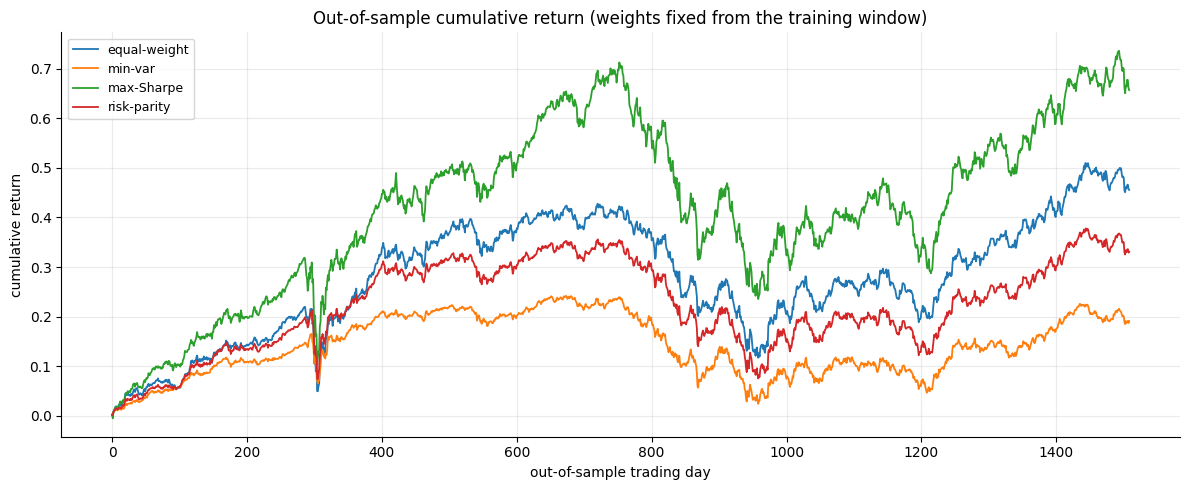

In [9]:
fig, ax = plt.subplots()
for label, build in builders.items():
    w = build()
    port_ret = test @ w
    ax.plot(np.cumprod(1 + port_ret) - 1, lw=1.3, label=label)
ax.set_title('Out-of-sample cumulative return (weights fixed from the training window)')
ax.set_ylabel('cumulative return'); ax.set_xlabel('out-of-sample trading day'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Turnover & costs.** Re-optimising every day churns the book; add a turnover
  penalty or rebalance on a schedule and net realised returns against costs.
* **Better $\mu$.** Max-Sharpe lives or dies on the return estimate. Shrink it
  too (James–Stein), or use **Black–Litterman** to blend a market-equilibrium
  prior with your views.
* **Conditional covariance.** Feed a **DCC-GARCH** $H_t$ (see the GARCH tutorial)
  for a covariance that tracks regimes instead of one static estimate.
* **Constraints.** Real mandates cap single-name weights, sector exposure, and
  leverage — all expressible as extra constraints in the same SLSQP solver.
